# Configuration

In [55]:
# Jupyter Config
%load_ext autoreload
%autoreload 2

# Imports
import step1_videofiles as vf
import step2_datasets as ds
import step3_parse as ps
import step4_ngrams as sg
import step5_testtrainsplit as tt
import step6_sourcedigest as sd
import step7_similarity as sl
import step8_curves as cr
import pandas as pd

# Ngrams
NGRAM_SIZES = [2, 3, 4]
NGRAM_SIZE = 2

# Files
TRAIN = r".\5_testtrainsplit\5_train.csv"
TEST  = r".\5_testtrainsplit\5_test.csv"
INPUT  = r".\5_testtrainsplit\5_train.csv"
DIGESTS = r".\6_sourcedigest\6_source_digests.csv"

# Filters
_devices = [
    "D01", "D02", "D03", "D04", "D05", "D06", "D08", "D09", "D10", "D11", "D12", "D13", "D14", "D15", "D16", "D17", "D18", "D19", "D20", 
    "D21", "D22", "D23", "D24", "D25", "D26", "D27", "D28", "D29", "D30", "D31", "D32", "D33", "D34", "D35"
]

_models = [
    "iPad2", "iPadmini", "iPhone4", "iPhone4s", "iPhone5", "iPhone5c", "iPhone6", "iPhone6Plus",
    "Zenfone2Laser", "AscendG6", "Honor5", "P89", "P9", "P9lite", "D290", "Lumia640LTE",
    "A3000", "A3003", "GalaxyS3", "GalaxyS3Mini", "GalaxyS4Mini", "GalaxyS5",
    "GalaxyTab3", "GalaxyTabA", "GalaxyTrendPlus", "XperiaZ1Compact", "Ridge4G", "RedmiNote3",
]

_brands = ["Apple", "Asus", "Huawei", "LG", "Microsoft", "OnePlus", "Samsung", "Sony", "Wiko", "Xiaomi"]

_socials = ["WHATSAPP", "YOUTUBE", "FACEBOOK", "TIKTOK", "WEIBO"]

_ais = ["OmniFlash", "Veo3.1", "Imagine0.9", "Imagine1.5", "KlingAIVideo2.6", "KlingAIVideo3.0", "Sora2", "Pika1.5", "Pika2.0", "Pika2.2", "Pika2.5"]

_aitypes = ["SYNTHETIC", "DEEPFAKE"]

_tampered = ["native", "avidemux", "exiftool", "ffmpeg1", "ffmpeg2", "ffmpeg3", "ffmpeg4", "ffmpeg5", "kdenlive", "premiere"]

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Reading file paths

In [56]:
input1 = [
    {
        "input_dir": r"C:\DB\AI",
        "output_csv": r".\1_videofiles\1_ai.csv"
    },
    {
        "input_dir": r"C:\DB\EVA-7K",
        "output_csv": r".\1_videofiles\1_eva.csv"
    },
    {
        "input_dir": r"C:\DB\VISION",
        "output_csv": r".\1_videofiles\1_vision.csv"
    }
]

for i in input1:
    vf.extract_video_paths(i['input_dir'], i['output_csv'])

Found 61 video files. Exported to: .\1_videofiles\1_ai.csv
Found 5600 video files. Exported to: .\1_videofiles\1_eva.csv
Found 1889 video files. Exported to: .\1_videofiles\1_vision.csv


# Structuring data sets

In [57]:
ds.process_selfmade_ai(
        r".\1_videofiles\1_ai.csv", 
        r".\2_datasets\2_ai.csv")

ds.process_vision(
        r".\1_videofiles\1_vision.csv", 
        r".\2_datasets\2_vision.csv")

ds.process_eva(
        r".\1_videofiles\1_eva.csv", 
        r".\2_datasets\2_eva.csv")

61 entries processed. Exported to: .\2_datasets\2_ai.csv
1889 entries processed. Exported to: .\2_datasets\2_vision.csv
5600 entries processed. Exported to: .\2_datasets\2_eva.csv


# Analyze video structure

In [58]:
input3 = [
    {
        "input_csv": r".\2_datasets\2_ai.csv",
        "output_csv": r".\3_parse\3_ai.csv"
    },
    {
        "input_csv": r".\2_datasets\2_eva.csv",
        "output_csv": r".\3_parse\3_eva.csv"
    },
    {
        "input_csv": r".\2_datasets\2_vision.csv",
        "output_csv": r".\3_parse\3_vision.csv"
    }
]

for i in input3: 
    ps.process_dataset_with_pandas(i['input_csv'], i['output_csv'])

Loading dataset from: .\2_datasets\2_ai.csv
Parsing... 61/61
Processed 61 files. Exported to: .\3_parse\3_ai.csv
Loading dataset from: .\2_datasets\2_eva.csv
Parsing... 500/5600
Parsing... 1000/5600
Parsing... 1500/5600
Parsing... 2000/5600
Parsing... 2500/5600
Parsing... 3000/5600
Parsing... 3500/5600
Parsing... 4000/5600
Parsing... 4500/5600
Parsing... 5000/5600
Parsing... 5500/5600
Parsing... 5600/5600
Processed 5600 files. Exported to: .\3_parse\3_eva.csv
Loading dataset from: .\2_datasets\2_vision.csv
Parsing... 500/1889
Parsing... 1000/1889
Parsing... 1500/1889
Parsing... 1889/1889
Processed 1889 files. Exported to: .\3_parse\3_vision.csv


# Calculate n-grams as a similarity digest

In [59]:
input4 = [
    {
        "input_csv": r".\3_parse\3_ai.csv",
        "output_csv": r".\4_ngrams\4_ai.csv"
    },
    {
        "input_csv": r".\3_parse\3_eva.csv",
        "output_csv": r".\4_ngrams\4_eva.csv"
    },
    {
        "input_csv": r".\3_parse\3_vision.csv",
        "output_csv": r".\4_ngrams\4_vision.csv"
    }
]

for i in input4: 
    sg.process_ngrams(i['input_csv'], i['output_csv'], NGRAM_SIZES)

Loading dataset: .\3_parse\3_ai.csv
Exported dataset with 61 Similarity Digests to: .\4_ngrams\4_ai.csv
Loading dataset: .\3_parse\3_eva.csv
Exported dataset with 5600 Similarity Digests to: .\4_ngrams\4_eva.csv
Loading dataset: .\3_parse\3_vision.csv
Exported dataset with 1889 Similarity Digests to: .\4_ngrams\4_vision.csv


# Divide in training and test (remaining files) data


In [60]:

tt.split_dataset(
    input_files=[
        r".\4_ngrams\4_ai.csv",
        r".\4_ngrams\4_vision.csv",
        r".\4_ngrams\4_eva.csv",
    ],
    train_output=TRAIN,
    test_output=TEST,
    train_selector=["every_second", "first", "_0001"],
)

Loaded 61 rows from .\4_ngrams\4_ai.csv (selector='every_second')
Loaded 1889 rows from .\4_ngrams\4_vision.csv (selector='first')
Loaded 5600 rows from .\4_ngrams\4_eva.csv (selector='_0001')
Training (reference): 3501 rows -> .\5_testtrainsplit\5_train.csv
Test (query):         4049 rows -> .\5_testtrainsplit\5_test.csv


# Generate Source Digest, Calculate Similarity, Graphs

## Native

### Brand

In [ ]:
#Source Digest
input6_brands = [{"filters": {"brand": b, "processing": "ORIGINAL"}} for b in _brands]
for i in input6_brands:
    sd.create_source_digest(TRAIN, DIGESTS, filters=i["filters"], label=i.get("label"))

NameError: name 'OUTPUT' is not defined

In [ ]:
# Similarity
OUTPUT_DIR = r".\7_similarity\brands"
_filters   = {"processing": "ORIGINAL", "content_source": "DIGITAL_CAMERA"}
input7_brands = [{"source_label": f"{b}_original", "test_filters": _filters} for b in _brands]
for i in input7_brands:
    sl.compute_similarity(
        output_dir=OUTPUT_DIR,
        source_file=DIGESTS,
        source_label=i["source_label"],
        test_file=TEST,
        test_filters=i["test_filters"],
    )

In [ ]:
# Graph
TITLE=f"Similarity Hash Performance - Hersteller - {NGRAM_SIZE}-Gram"
INPUT_CSVS = r".\7_similarity\brands"
OUTPUT_NAME="brands.png"
cr.plot_roc(
    input_csvs=INPUT_CSVS,
    ngram_size=NGRAM_SIZE,
    output_dir=r".\8_curves",
    output_name=OUTPUT_NAME,
    title=TITLE,
    show_mean=True,
    export_auc=True
)

### Model

In [ ]:
#Source Digest
input6_models = [{"filters": {"model": m, "processing": "ORIGINAL"}} for m in _models]
for i in input6_models:
    sd.create_source_digest(TRAIN, DIGESTS, filters=i["filters"], label=i.get("label"))

In [ ]:
# Similarity
OUTPUT_DIR = r".\7_similarity\models"
filters   = {"processing": "ORIGINAL", "content_source": "DIGITAL_CAMERA"}
input7_models = [{"source_label": f"{m}_ORIGINAL", "test_filters": _filters} for m in _models]
for i in input7_models:
    sl.compute_similarity(
        output_dir=OUTPUT_DIR,
        source_file=DIGESTS,
        source_label=i["source_label"],
        test_file=TEST,
        test_filters=i["test_filters"],
    )

In [ ]:
# Graph
TITLE=f"Similarity Hash Performance - Modell - {NGRAM_SIZE}-Gram"
INPUT_CSVS = r".\7_similarity\models"
OUTPUT_NAME="models.png"
cr.plot_roc(
    input_csvs=INPUT_CSVS,
    ngram_size=NGRAM_SIZE,
    output_dir=r".\8_curves",
    output_name=OUTPUT_NAME,
    title=TITLE,
    show_mean=True,
    export_auc=True
)

### Device

In [ ]:
#Source Digest
input6_devices = [{"filters": {"id": d, "processing": "ORIGINAL"}} for d in _devices]
for i in input6_devices:
    sd.create_source_digest(TRAIN, DIGESTS, filters=i["filters"], label=i.get("label"))

In [ ]:
# Similarity
OUTPUT_DIR = r".\7_similarity\devices"
_filters   = {"processing": "ORIGINAL", "content_source": "DIGITAL_CAMERA"}
input7_devices = [{"source_label": f"{d}_ORIGINAL", "test_filters": _filters} for d in _devices]
for i in input7_devices:
    sl.compute_similarity(
        output_dir=OUTPUT_DIR,
        source_file=DIGESTS,
        source_label=i["source_label"],
        test_file=TEST,
        test_filters=i["test_filters"],
    )

In [ ]:
# Graph
TITLE=f"Similarity Hash Performance - Geräte - {NGRAM_SIZE}-Gram"
INPUT_CSVS = r".\7_similarity\devices"
OUTPUT_NAME="devices.png"
cr.plot_roc(
    input_csvs=INPUT_CSVS,
    ngram_size=NGRAM_SIZE,
    output_dir=r".\8_curves",
    output_name=OUTPUT_NAME,
    title=TITLE,
    show_mean=True,
    export_auc=True
)

## Social Media

In [ ]:
# Source Digest
input6_socials = [
    {"filters": {"processing": s, "tampering": "NATIVE"},}
    for s in _socials
]
for i in input6_socials:
    sd.create_source_digest(TRAIN, DIGESTS, filters=i["filters"])

In [ ]:
# Similarity
OUTPUT_DIR = r".\7_similarity\sm"
_filters   = {"processing": _socials, "tampering": "NATIVE"} 
input7_socials = [{"source_label": f"{s}_native", "test_filters": _filters} for s in _socials]
for i in input7_socials:
    sl.compute_similarity(
        output_dir=OUTPUT_DIR,
        source_file=DIGESTS,
        source_label=i["source_label"],
        test_file=TEST,
        test_filters=i["test_filters"],
    )

In [ ]:
# Graph
TITLE=f"Similarity Hash Performance - Social Media - {NGRAM_SIZE}-Gram"
INPUT_CSVS = r".\7_similarity\sm"
OUTPUT_NAME="sm.png"
cr.plot_roc(
    input_csvs=INPUT_CSVS,
    ngram_size=NGRAM_SIZE,
    output_dir=r".\8_curves",
    output_name=OUTPUT_NAME,
    title=TITLE,
    show_mean=True,
    export_auc=True
)

## AI

### AI Model

In [ ]:
# Source Digest
input6_ais = [{"filters": {"model": a}} for a in _ais]
for i in input6_ais:
    sd.create_source_digest(TRAIN, DIGESTS, filters=i["filters"], label=i.get("label"))

Source digest 'OmniFlash': 2 files aggregated -> .\6_sourcedigest\6_source_digests.csv
Source digest 'Veo3.1': 2 files aggregated -> .\6_sourcedigest\6_source_digests.csv
Source digest 'Imagine0.9': 1 files aggregated -> .\6_sourcedigest\6_source_digests.csv
Source digest 'Imagine1.5': 7 files aggregated -> .\6_sourcedigest\6_source_digests.csv
Source digest 'KlingAIVideo2.6': 1 files aggregated -> .\6_sourcedigest\6_source_digests.csv
Source digest 'KlingAIVideo3.0': 1 files aggregated -> .\6_sourcedigest\6_source_digests.csv
Source digest 'Sora2': 5 files aggregated -> .\6_sourcedigest\6_source_digests.csv
Source digest 'Pika1.5': 2 files aggregated -> .\6_sourcedigest\6_source_digests.csv
Source digest 'Pika2.0': 2 files aggregated -> .\6_sourcedigest\6_source_digests.csv
Source digest 'Pika2.2': 2 files aggregated -> .\6_sourcedigest\6_source_digests.csv
Source digest 'Pika2.5': 6 files aggregated -> .\6_sourcedigest\6_source_digests.csv


In [ ]:
# Similarity
OUTPUT_DIR = r".\7_similarity\ai"
_filters   = {"db_name": "AI"} 
input7_ais = [{"source_label": a, "test_filters": _filters} for a in _ais]
for i in input7_ais:
    sl.compute_similarity(
        output_dir=OUTPUT_DIR,
        source_file=DIGESTS,
        source_label=i["source_label"],
        test_file=TEST,
        test_filters=i["test_filters"],
    )

Finished! 30 rows -> .\7_similarity\ai\OmniFlash_vs_db_name_AI.csv
Finished! 30 rows -> .\7_similarity\ai\Veo3.1_vs_db_name_AI.csv
Finished! 30 rows -> .\7_similarity\ai\Imagine0.9_vs_db_name_AI.csv
Finished! 30 rows -> .\7_similarity\ai\Imagine1.5_vs_db_name_AI.csv
Finished! 30 rows -> .\7_similarity\ai\KlingAIVideo2.6_vs_db_name_AI.csv
Finished! 30 rows -> .\7_similarity\ai\KlingAIVideo3.0_vs_db_name_AI.csv
Finished! 30 rows -> .\7_similarity\ai\Sora2_vs_db_name_AI.csv
Finished! 30 rows -> .\7_similarity\ai\Pika1.5_vs_db_name_AI.csv
Finished! 30 rows -> .\7_similarity\ai\Pika2.0_vs_db_name_AI.csv
Finished! 30 rows -> .\7_similarity\ai\Pika2.2_vs_db_name_AI.csv
Finished! 30 rows -> .\7_similarity\ai\Pika2.5_vs_db_name_AI.csv


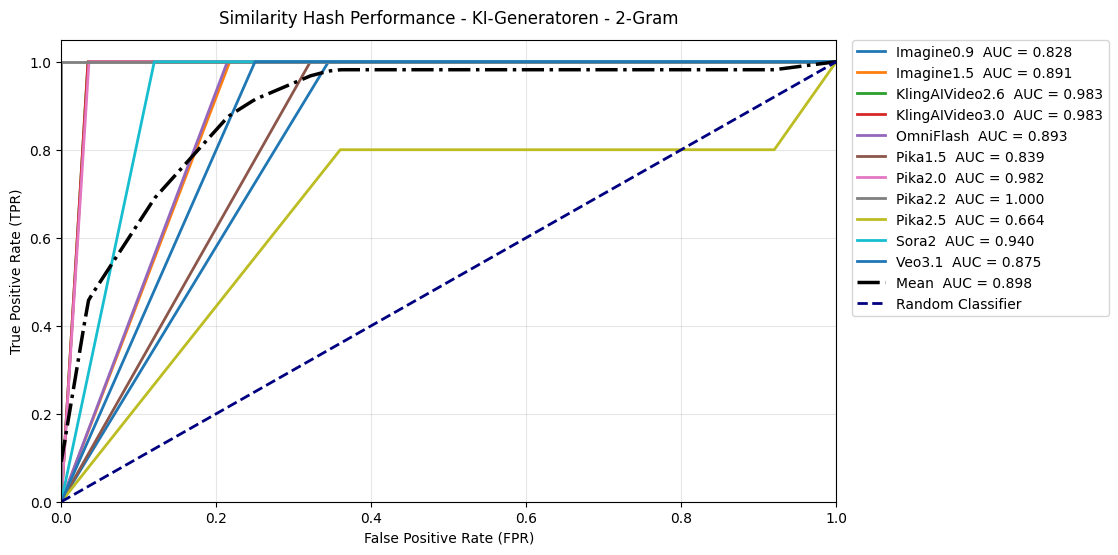

Saved -> .\8_curves\ai.png


In [ ]:
# Graph
TITLE=f"Similarity Hash Performance - KI-Generatoren - {NGRAM_SIZE}-Gram"
INPUT_CSVS = r".\7_similarity\ai"
OUTPUT_NAME="ai.png"
cr.plot_roc(
    input_csvs=INPUT_CSVS,
    ngram_size=NGRAM_SIZE,
    output_dir=r".\8_curves",
    output_name=OUTPUT_NAME,
    title=TITLE,
    show_mean=True,
    export_auc=True
)

### Deepfake or Synth

In [ ]:
# Filter
train_ai = r".\5_testtrainsplit\5_train_ai.csv"
test_ai = r".\5_testtrainsplit\5_test_ai.csv"

_ids = ['AI01', 'AI02', 'AI04', 'AI07', 'AI11']

df = pd.read_csv(TRAIN, sep=";",engine='python')
df_filtered = df[(df['id'].isin(_ids)) & (df['content_type'].isin(_aitypes))]
df_filtered.to_csv(train_ai, sep=';', index=False, encoding='utf-8')

df = pd.read_csv(TEST, sep=";",engine='python')
df_filtered = df[(df['id'].isin(_ids)) & (df['content_type'].isin(_aitypes))]
df_filtered.to_csv(test_ai, sep=';', index=False, encoding='utf-8')

In [ ]:
# Source Digest
input6_aitypes = [{"filters": {"content_type": a}} for a in _aitypes]
for i in input6_aitypes:
    sd.create_source_digest(train_ai, DIGESTS, filters=i["filters"], label=i.get("label"))

Source digest 'SYNTHETIC': 10 files aggregated -> .\6_sourcedigest\6_source_digests.csv
Source digest 'DEEPFAKE': 12 files aggregated -> .\6_sourcedigest\6_source_digests.csv


In [ ]:
# Similarity
OUTPUT_DIR = r".\7_similarity\dfsynth"
_filters   = {"db_name": "AI"} 
input7_aitypes = [{"source_label": a, "test_filters": _filters} for a in _aitypes]
for i in input7_aitypes:
    sl.compute_similarity(
        output_dir=OUTPUT_DIR,
        source_file=DIGESTS,
        source_label=i["source_label"],
        test_file=test_ai,
        test_filters=i["test_filters"],
    )

Finished! 21 rows -> .\7_similarity\dfsynth\SYNTHETIC_vs_db_name_AI.csv
Finished! 21 rows -> .\7_similarity\dfsynth\DEEPFAKE_vs_db_name_AI.csv


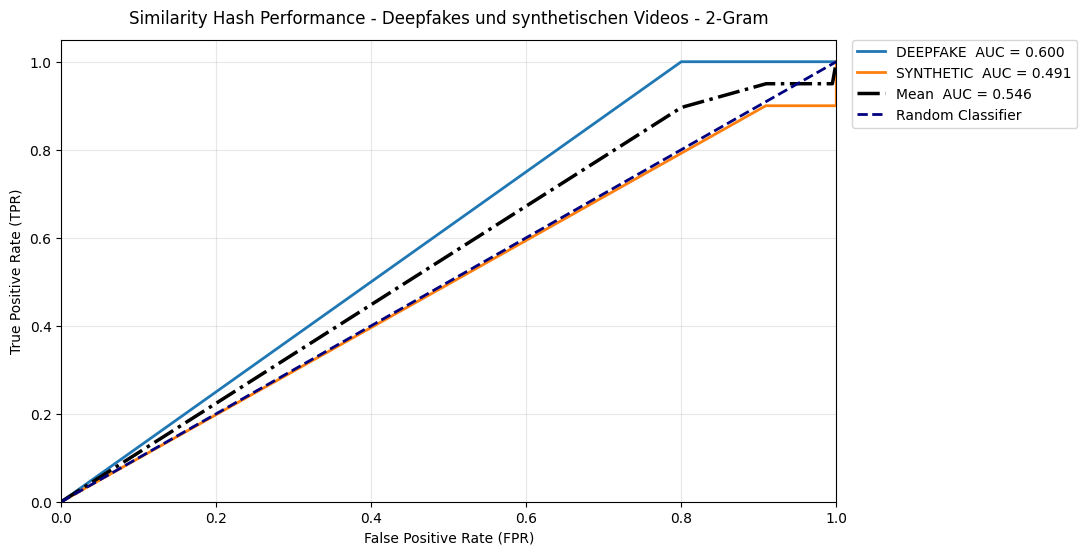

Saved -> .\8_curves\dfsynth.png


In [ ]:
# Graph
TITLE=f"Similarity Hash Performance - Deepfakes und synthetischen Videos - {NGRAM_SIZE}-Gram"
INPUT_CSVS = r".\7_similarity\dfsynth"
OUTPUT_NAME="dfsynth.png"
cr.plot_roc(
    input_csvs=INPUT_CSVS,
    ngram_size=NGRAM_SIZE,
    output_dir=r".\8_curves",
    output_name=OUTPUT_NAME,
    title=TITLE,
    show_mean=True,
    export_auc=True
)

# Mixed

## Tampered

In [ ]:
# Source Digest
input6_tampered = [{"filters": {"content_source": "DIGITAL_CAMERA", "tampering": t}} for t in _tampered]
for i in input6_tampered:
    sd.create_source_digest(TRAIN, DIGESTS, filters=i["filters"], label=i.get("label"))

Source digest 'DIGITAL_CAMERA_native': 628 files aggregated -> .\6_sourcedigest\6_source_digests.csv
Source digest 'DIGITAL_CAMERA_avidemux': 316 files aggregated -> .\6_sourcedigest\6_source_digests.csv
Source digest 'DIGITAL_CAMERA_exiftool': 316 files aggregated -> .\6_sourcedigest\6_source_digests.csv
Source digest 'DIGITAL_CAMERA_ffmpeg1': 316 files aggregated -> .\6_sourcedigest\6_source_digests.csv
Source digest 'DIGITAL_CAMERA_ffmpeg2': 316 files aggregated -> .\6_sourcedigest\6_source_digests.csv
Source digest 'DIGITAL_CAMERA_ffmpeg3': 316 files aggregated -> .\6_sourcedigest\6_source_digests.csv
Source digest 'DIGITAL_CAMERA_ffmpeg4': 316 files aggregated -> .\6_sourcedigest\6_source_digests.csv
Source digest 'DIGITAL_CAMERA_ffmpeg5': 316 files aggregated -> .\6_sourcedigest\6_source_digests.csv
Source digest 'DIGITAL_CAMERA_kdenlive': 314 files aggregated -> .\6_sourcedigest\6_source_digests.csv
Source digest 'DIGITAL_CAMERA_premiere': 316 files aggregated -> .\6_sourcediges

In [ ]:
# Similarity
OUTPUT_DIR = r".\7_similarity\tampered"
_filters   = {"content_source": "DIGITAL_CAMERA"} 
input7_tampered = [{"source_label": f"DIGITAL_CAMERA_{t}", "test_filters": _filters} for t in _tampered]
for i in input7_tampered:
    sl.compute_similarity(
        output_dir=OUTPUT_DIR,
        source_file=DIGESTS,
        source_label=i["source_label"],
        test_file=TEST,
        test_filters=i["test_filters"],
    )

Finished! 4019 rows -> .\7_similarity\tampered\DIGITAL_CAMERA_native_vs_content_source_DIGITAL_CAMERA.csv
Finished! 4019 rows -> .\7_similarity\tampered\DIGITAL_CAMERA_avidemux_vs_content_source_DIGITAL_CAMERA.csv
Finished! 4019 rows -> .\7_similarity\tampered\DIGITAL_CAMERA_exiftool_vs_content_source_DIGITAL_CAMERA.csv
Finished! 4019 rows -> .\7_similarity\tampered\DIGITAL_CAMERA_ffmpeg1_vs_content_source_DIGITAL_CAMERA.csv
Finished! 4019 rows -> .\7_similarity\tampered\DIGITAL_CAMERA_ffmpeg2_vs_content_source_DIGITAL_CAMERA.csv
Finished! 4019 rows -> .\7_similarity\tampered\DIGITAL_CAMERA_ffmpeg3_vs_content_source_DIGITAL_CAMERA.csv
Finished! 4019 rows -> .\7_similarity\tampered\DIGITAL_CAMERA_ffmpeg4_vs_content_source_DIGITAL_CAMERA.csv
Finished! 4019 rows -> .\7_similarity\tampered\DIGITAL_CAMERA_ffmpeg5_vs_content_source_DIGITAL_CAMERA.csv
Finished! 4019 rows -> .\7_similarity\tampered\DIGITAL_CAMERA_kdenlive_vs_content_source_DIGITAL_CAMERA.csv
Finished! 4019 rows -> .\7_similari

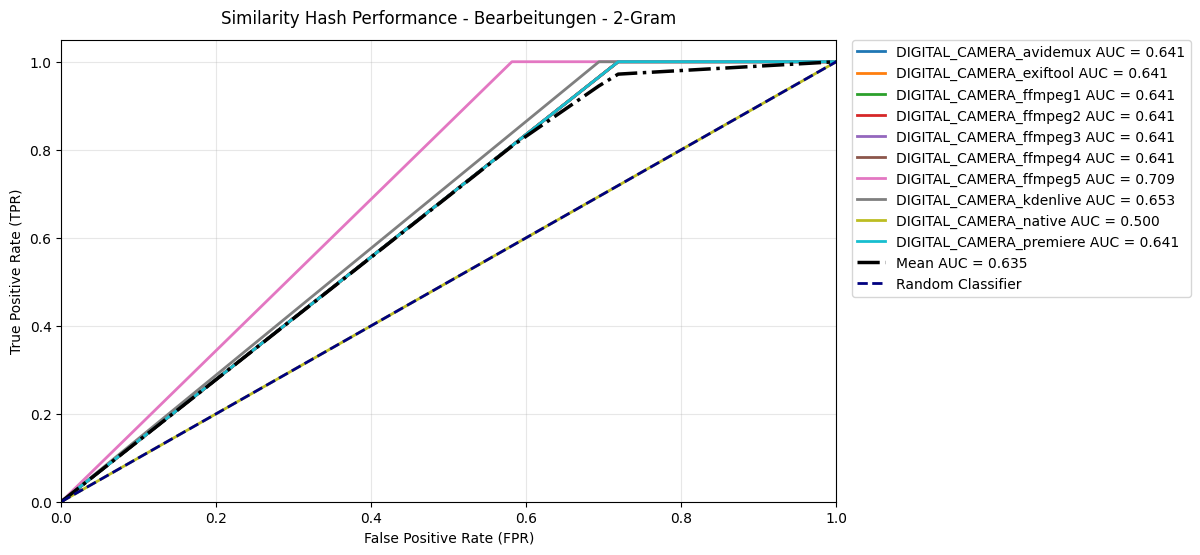

Saved -> .\8_curves\tampered.png


In [ ]:
# Graph
TITLE=f"Similarity Hash Performance - Bearbeitungen - {NGRAM_SIZE}-Gram"
INPUT_CSVS = r".\7_similarity\tampered"
OUTPUT_NAME="tampered.png"
cr.plot_roc(
    input_csvs=INPUT_CSVS,
    ngram_size=NGRAM_SIZE,
    output_dir=r".\8_curves",
    output_name=OUTPUT_NAME,
    title=TITLE,
    show_mean=True,
    export_auc=True
)

## Native vs AI vs Social Media

### ohne Bearbeitungen

In [ ]:
# Source Digest
input6_mixed = [
    {"filters": {"content_source": "DIGITAL_CAMERA", "processing": "ORIGINAL"}},  # Native
    {"filters": {"db_name": "AI"}},                                               # AI
    {"filters": {"processing_sm": "True", "tampering": "NATIVE"}},                # Social Media
]
for i in input6_mixed:
    sd.create_source_digest(TRAIN, DIGESTS, filters=i["filters"], label=i.get("label"))

Source digest 'DIGITAL_CAMERA_ORIGINAL': 102 files aggregated -> .\6_sourcedigest\6_source_digests.csv
Source digest 'AI': 31 files aggregated -> .\6_sourcedigest\6_source_digests.csv
Source digest 'True_NATIVE': 526 files aggregated -> .\6_sourcedigest\6_source_digests.csv


In [ ]:
# Similarity
OUTPUT_DIR = r".\7_similarity\mixed"
_filters = {"tampering": "NATIVE"}
input7_mixed = [
    {"source_label": "DIGITAL_CAMERA_ORIGINAL", "test_filters": _filters},
    {"source_label": "AI", "test_filters": _filters},
    {"source_label": "True_NATIVE", "test_filters": _filters}
]
for i in input7_mixed:
    sl.compute_similarity(
        output_dir=OUTPUT_DIR,
        source_file=DIGESTS,
        source_label=i["source_label"],
        test_file=TEST,
        test_filters=i["test_filters"],
    )

Finished! 4049 rows -> .\7_similarity\mixed\DIGITAL_CAMERA_ORIGINAL_vs_all.csv
Finished! 4049 rows -> .\7_similarity\mixed\AI_vs_all.csv
Finished! 4049 rows -> .\7_similarity\mixed\True_NATIVE_vs_all.csv


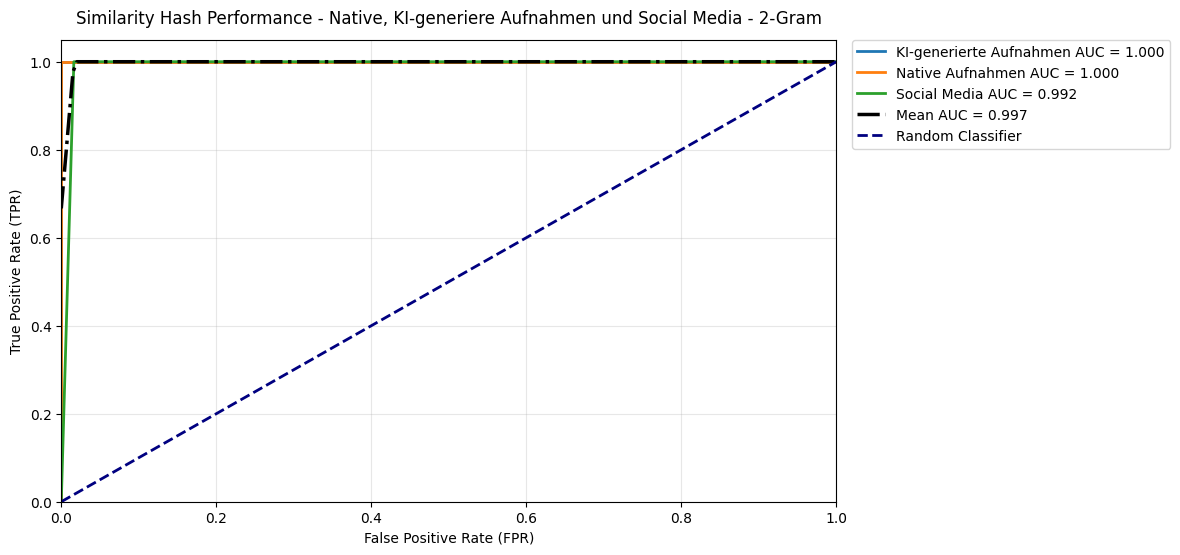

Saved -> .\8_curves\mixed.png


In [ ]:
# Graph
TITLE=f"Similarity Hash Performance - Native, KI-generiere Aufnahmen und Social Media - {NGRAM_SIZE}-Gram"

INPUT_CSVS=[
    (r".\7_similarity\mixed\AI_vs_tampering_NATIVE.csv", "KI-generierte Aufnahmen"),
    (r".\7_similarity\mixed\DIGITAL_CAMERA_ORIGINAL_vs_tampering_NATIVE.csv", "Native Aufnahmen"),
    (r".\7_similarity\mixed\True_NATIVE_vs_tampering_NATIVE.csv", "Social Media"),
]

OUTPUT_NAME="mixed.png"
cr.plot_roc(
    input_csvs=INPUT_CSVS,
    ngram_size=NGRAM_SIZE,
    output_dir=r".\8_curves",
    
    output_name=OUTPUT_NAME,
    title=TITLE,
    show_mean=True,
    export_auc=True
)

### mit Bearbeitungen

In [ ]:
# Similarity
OUTPUT_DIR = r".\7_similarity\mixed"
_filters = None
input7_mixed = [
    {"source_label": "DIGITAL_CAMERA_ORIGINAL", "test_filters": _filters},
    {"source_label": "AI", "test_filters": _filters},
    {"source_label": "True_NATIVE", "test_filters": _filters}
]
for i in input7_mixed:
    sl.compute_similarity(
        output_dir=OUTPUT_DIR,
        source_file=DIGESTS,
        source_label=i["source_label"],
        test_file=TEST,
        test_filters=i["test_filters"],
    )

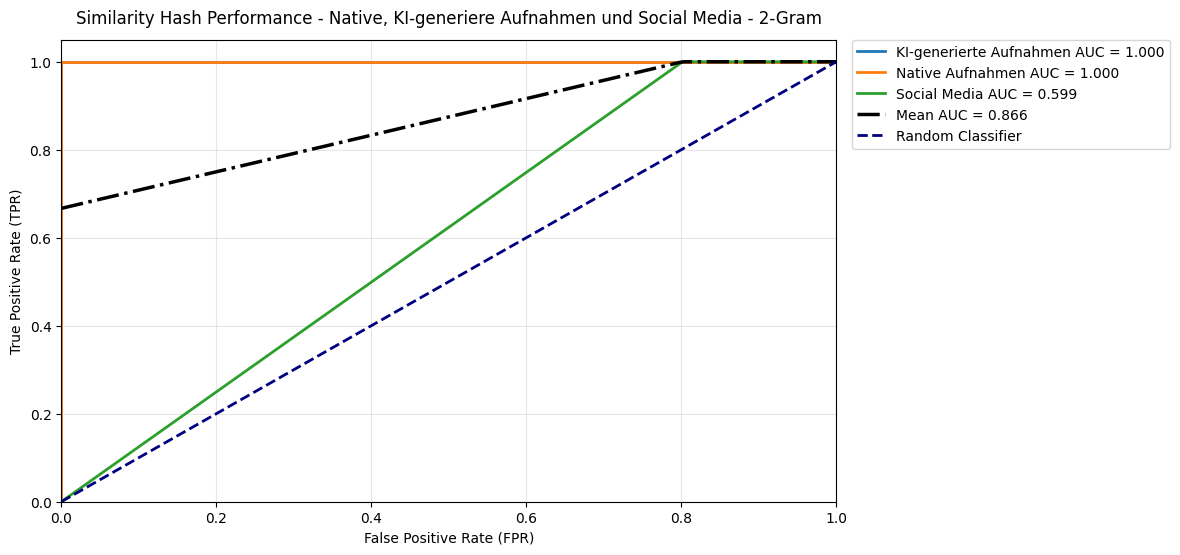

Saved -> .\8_curves\mixed.png


In [ ]:
# Graph
TITLE=f"Similarity Hash Performance - Native, KI-generiere Aufnahmen und Social Media - {NGRAM_SIZE}-Gram"

INPUT_CSVS=[
    (r".\7_similarity\mixed\AI_vs_all.csv", "KI-generierte Aufnahmen"),
    (r".\7_similarity\mixed\DIGITAL_CAMERA_ORIGINAL_vs_all.csv", "Native Aufnahmen"),
    (r".\7_similarity\mixed\True_NATIVE_vs_all.csv", "Social Media"),
]

OUTPUT_NAME="mixed.png"
cr.plot_roc(
    input_csvs=INPUT_CSVS,
    ngram_size=NGRAM_SIZE,
    output_dir=r".\8_curves",
    
    output_name=OUTPUT_NAME,
    title=TITLE,
    show_mean=True,
    export_auc=True
)